In [28]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

LR = 1e-3
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 5

print(f"TensorFlow {tf.__version__}")
print("Settings - LR:", LR, "| Batch:", BATCH_SIZE, "| Epochs:", EPOCHS)

TensorFlow 2.20.0
Settings - LR: 0.001 | Batch: 128 | Epochs: 30


In [14]:
def load_dataset(name):
    loader = keras.datasets.mnist if name == "mnist" else keras.datasets.fashion_mnist
    (x_full, y_full), (x_test, y_test) = loader.load_data()
    x_full = x_full.reshape(-1, 784).astype("float32") / 255.0
    x_test = x_test.reshape(-1, 784).astype("float32") / 255.0
    x_val,   y_val   = x_full[:10_000], y_full[:10_000]
    x_train, y_train = x_full[10_000:], y_full[10_000:]
    return x_train, y_train, x_val, y_val, x_test, y_test

x_train, y_train, x_val, y_val, x_test, y_test = load_dataset("mnist")
print("MNIST — train:", x_train.shape, "| val:", x_val.shape, "| test:", x_test.shape)

fx_train, fy_train, fx_val, fy_val, fx_test, fy_test = load_dataset("fashion_mnist")
print("Fashion — train:", fx_train.shape, "| val:", fx_val.shape, "| test:", fx_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST — train: (50000, 784) | val: (10000, 784) | test: (10000, 784)
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion — train: (50000, 784) | val: (10000, 784) | test: (10000, 784)


In [16]:
def build_arch_a():
    return keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(64,  activation="relu"),
        layers.Dense(10,  activation="softmax"),
    ], name="Arch_A_Shallow")

def build_arch_b():
    return keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(10,  activation="softmax"),
    ], name="Arch_B_Medium")

def build_arch_c():
    return keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(32,  activation="relu"),
        layers.Dense(10,  activation="softmax"),
    ], name="Arch_C_Deep")

for build_fn in [build_arch_a, build_arch_b, build_arch_c]:
    m = build_fn()
    print(f"{m.name} — params: {m.count_params():,}")

Arch_A_Shallow — params: 50,890
Arch_B_Medium — params: 109,386
Arch_C_Deep — params: 111,146


Training Arch A (shallow) ...
 test acc: 0.9699  |  time: 60.0s
Training Arch B (medium) ...
 test acc: 0.9746  |  time: 77.6s
Training Arch C (deep) ...
 test acc: 0.9766  |  time: 73.9s


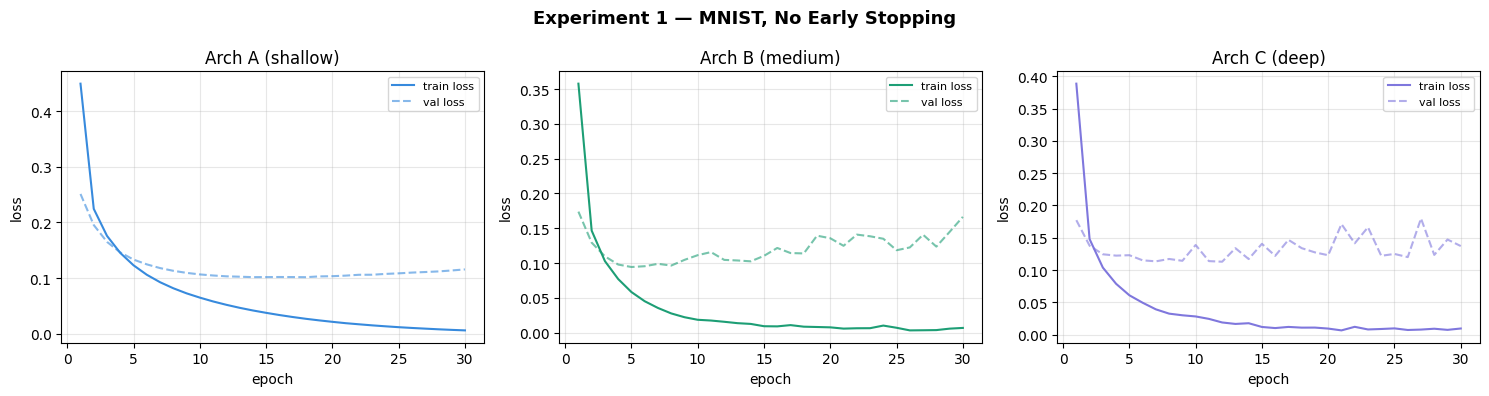

In [18]:
builders = [build_arch_a, build_arch_b, build_arch_c]
labels = ["Arch A (shallow)", "Arch B (medium)", "Arch C (deep)"]
colors = ["#378ADD", "#1D9E75", "#7F77DD"]

baseline_results = {}
for build_fn, label in zip(builders, labels):
    print(f"Training {label} ...")
    model = build_fn()
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    elapsed = time.time() - t0
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    baseline_results[label] = dict(history=history, test_acc=test_acc, elapsed=elapsed)
    print(f" test acc: {test_acc:.4f}  |  time: {elapsed:.1f}s")

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 1 — MNIST, No Early Stopping", fontsize=13, fontweight="bold")
for ax, (label, res), color in zip(axes, baseline_results.items(), colors):
    hist = res["history"].history
    ep = range(1, len(hist["loss"]) + 1)
    ax.plot(ep, hist["loss"],     color=color,   label="train loss")
    ax.plot(ep, hist["val_loss"], color=color,   label="val loss", linestyle="--", alpha=0.6)
    ax.set_title(label)
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Training Arch A (shallow) ...
->stopped at epoch 20/30  |  test acc: 0.9702  |  time: 33.5s
Training Arch B (medium) ...
->stopped at epoch 12/30  |  test acc: 0.9730  |  time: 40.1s
Training Arch C (deep) ...
->stopped at epoch 5/30  |  test acc: 0.9524  |  time: 16.4s


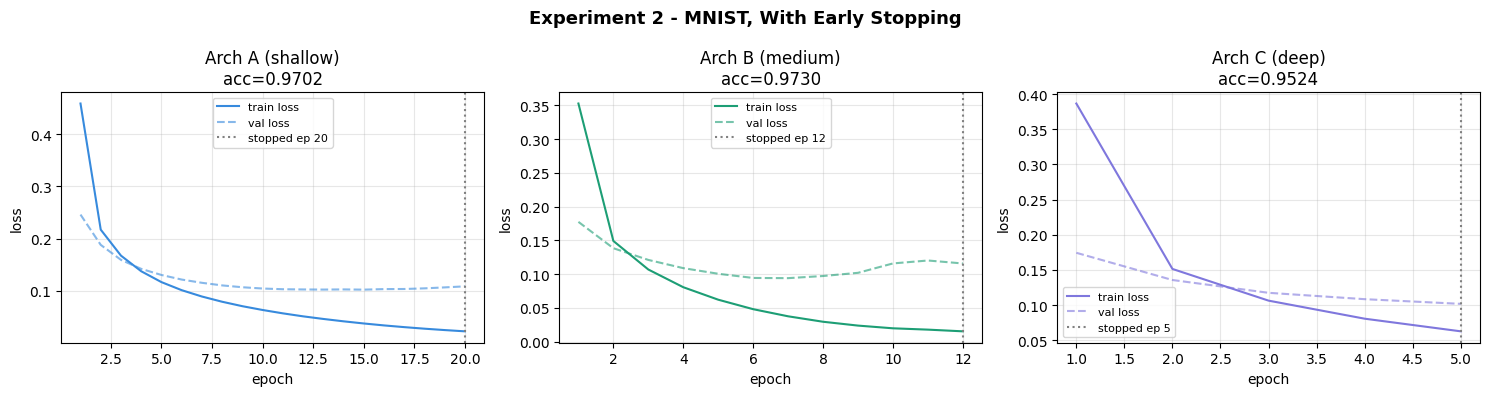

In [19]:
early_stop_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=0)

mnist_es = {}
for build_fn, label in zip(builders, labels):
    print(f"Training {label} ...")
    model = build_fn()
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop_cb], verbose=0)
    elapsed = time.time() - t0
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    stopped_at = len(history.history["loss"])
    mnist_es[label] = dict(history=history, test_acc=test_acc, elapsed=elapsed, stopped_at=stopped_at)
    print(f"->stopped at epoch {stopped_at}/{EPOCHS}  |  test acc: {test_acc:.4f}  |  time: {elapsed:.1f}s")

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 2 - MNIST, With Early Stopping", fontsize=13, fontweight="bold")
for ax, (label, res), color in zip(axes, mnist_es.items(), colors):
    hist = res["history"].history
    ep = range(1, len(hist["loss"]) + 1)
    ax.plot(ep, hist["loss"], color=color, label="train loss")
    ax.plot(ep, hist["val_loss"], color=color, label="val loss", linestyle="--", alpha=0.6)
    ax.axvline(res["stopped_at"], color="gray", linestyle=":", label=f"stopped ep {res['stopped_at']}")
    ax.set_title(f"{label}\nacc={res['test_acc']:.4f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Training Arch A (shallow) ...
 -> stopped at epoch 5/30  |  test acc: 0.8152  |  time: 9.9s
Training Arch B (medium) ...
 -> stopped at epoch 5/30  |  test acc: 0.8364  |  time: 14.5s
Training Arch C (deep) ...
 -> stopped at epoch 5/30  |  test acc: 0.8155  |  time: 14.6s


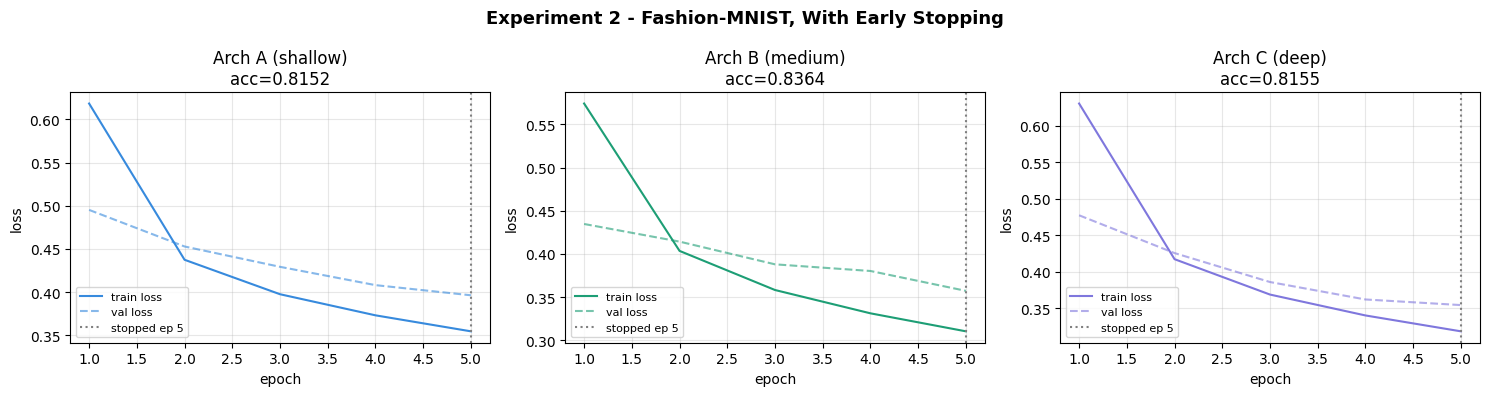

In [20]:
fashion_es = {}
for build_fn, label in zip(builders, labels):
    print(f"Training {label} ...")
    model = build_fn()
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    history = model.fit(fx_train, fy_train, validation_data=(fx_val, fy_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop_cb], verbose=0)
    elapsed = time.time() - t0
    _, test_acc = model.evaluate(fx_test, fy_test, verbose=0)
    stopped_at = len(history.history["loss"])
    fashion_es[label] = dict(history=history, test_acc=test_acc, elapsed=elapsed, stopped_at=stopped_at)
    print(f" -> stopped at epoch {stopped_at}/{EPOCHS}  |  test acc: {test_acc:.4f}  |  time: {elapsed:.1f}s")

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 2 - Fashion-MNIST, With Early Stopping", fontsize=13, fontweight="bold")
for ax, (label, res), color in zip(axes, fashion_es.items(), colors):
    hist = res["history"].history
    ep = range(1, len(hist["loss"]) + 1)
    ax.plot(ep, hist["loss"], color=color, label="train loss")
    ax.plot(ep, hist["val_loss"], color=color, label="val loss", linestyle="--", alpha=0.6)
    ax.axvline(res["stopped_at"], color="gray", linestyle=":", label=f"stopped ep {res['stopped_at']}")
    ax.set_title(f"{label}\nacc={res['test_acc']:.4f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

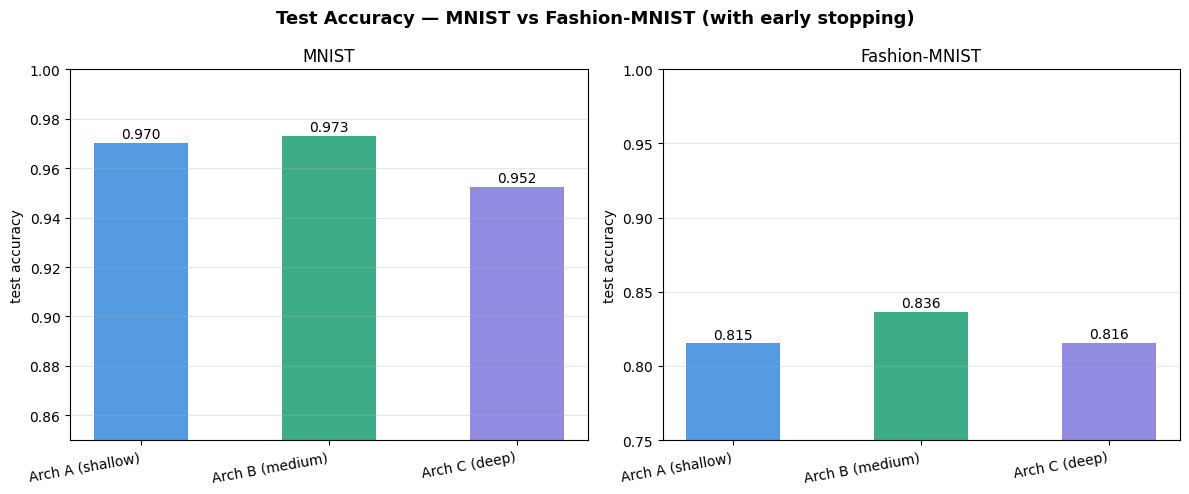


Summary Table
Architecture            MNIST acc   MNIST ep  Fashion acc   Fashion ep
----------------------------------------------------------------------
Arch A (shallow)           0.9702         20       0.8152            5
Arch B (medium)            0.9730         12       0.8364            5
Arch C (deep)              0.9524          5       0.8155            5


In [27]:
x_pos = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Test Accuracy — MNIST vs Fashion-MNIST (with early stopping)", fontsize=13, fontweight="bold")

for ax, results, title in [(ax1, mnist_es, "MNIST"), (ax2, fashion_es, "Fashion-MNIST")]:
    accs = [results[l]["test_acc"] for l in labels]
    bars = ax.bar(x_pos, accs, color=colors, alpha=0.85, width=0.5)
    ax.set_title(title)
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=10, ha="right")
    if title == "MNIST":
        ax.set_ylim(0.85, 1.0)
    else: # Fashion-MNIST
        ax.set_ylim(0.75, 1.0)
    ax.set_ylabel("test accuracy")
    ax.grid(axis="y", alpha=0.3)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001, f"{acc:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

print("\nSummary Table")
print(f"{'Architecture':<22} {'MNIST acc':>10} {'MNIST ep':>10} {'Fashion acc':>12} {'Fashion ep':>12}")
print("-" * 70)
for label in labels:
    m = mnist_es[label]
    f = fashion_es[label]
    print(f"{label:<22} {m['test_acc']:>10.4f} {m['stopped_at']:>10} {f['test_acc']:>12.4f} {f['stopped_at']:>12}")

Training Arch C with LR=100.0 (expect NaN)
NaN did not appear (try increasing LR further if needed)

Training Arch C with LR=0.001 + clipnorm=1.0 (fixed & effective)
 -> fixed test acc: 0.9736


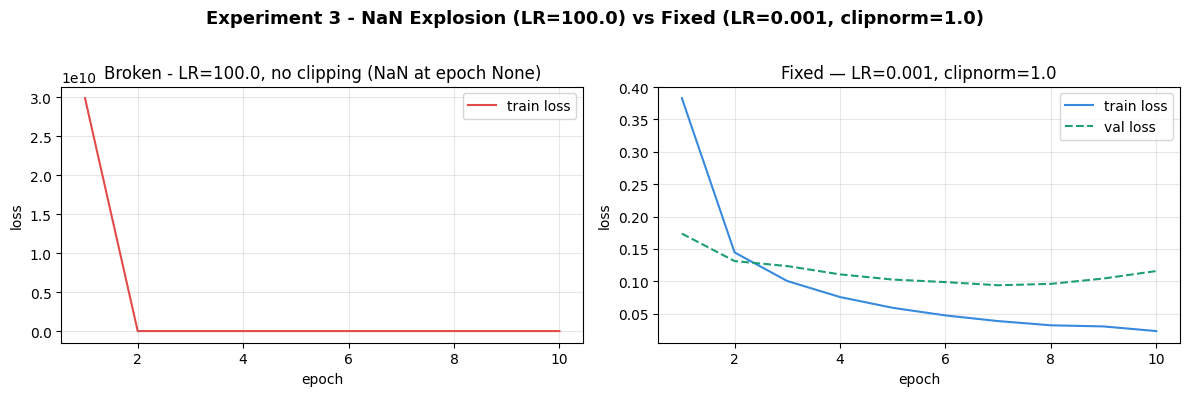

In [31]:
# broken: LR too high -> NaN
print("Training Arch C with LR=100.0 (expect NaN)")
model_broken = build_arch_c()
model_broken.compile(optimizer=keras.optimizers.Adam(learning_rate=100.0), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_broken = model_broken.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=BATCH_SIZE, verbose=0)
nan_epoch = next((i + 1 for i, v in enumerate(history_broken.history["loss"]) if np.isnan(v)), None)
if nan_epoch:
    print(f"NaN appeared at epoch: {nan_epoch}")
else:
    print("NaN did not appear (try increasing LR further if needed)")

# fixed: use a good LR with gradient clipping for stable and effective training
print(f"\nTraining Arch C with LR={LR} + clipnorm=1.0 (fixed & effective)")
model_fixed = build_arch_c()
model_fixed.compile(optimizer=keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_fixed = model_fixed.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=BATCH_SIZE, verbose=0)
_, fixed_acc = model_fixed.evaluate(x_test, y_test, verbose=0)
print(f" -> fixed test acc: {fixed_acc:.4f}")

# both plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Experiment 3 - NaN Explosion (LR=100.0) vs Fixed (LR={LR}, clipnorm=1.0)", fontsize=13, fontweight="bold")

epochs_b = range(1, len(history_broken.history["loss"]) + 1)
ax1.plot(epochs_b, history_broken.history["loss"], color="#E24B4A", label="train loss")
if nan_epoch:
    ax1.axvline(nan_epoch, color="#BA7517", linestyle="--", label=f"NaN at epoch {nan_epoch}")
ax1.set_title(f"Broken - LR=100.0, no clipping (NaN at epoch {nan_epoch if nan_epoch else 'None'})")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.legend(); ax1.grid(alpha=0.3)

epochs_f = range(1, len(history_fixed.history["loss"]) + 1)
ax2.plot(epochs_f, history_fixed.history["loss"], color="#378ADD", label="train loss")
ax2.plot(epochs_f, history_fixed.history["val_loss"], color="#1D9E75", label="val loss", linestyle="--")
ax2.set_title(f"Fixed — LR={LR}, clipnorm=1.0")
ax2.set_xlabel("epoch"); ax2.set_ylabel("loss")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()